# Regressão Logística - SLCE3 (Dataset Janelas)
## Análise comparativa de modelos de Machine Learning - Agro Brasil - TCC

Este notebook implementa modelos de regressão logística para prever se o preço de fechamento das ações SLCE3 irá subir ou não em diferentes horizontes temporais (3, 7, 15 e 30 dias).

**Dataset utilizado:** Dataset com janelas temporais (features com lags).

**Target:** Classificação binária (1 = Alta, 0 = Baixa/Estável)

### Importação das bibliotecas e carregamento do dataset

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, accuracy_score, precision_score, 
                             recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Configuração para salvar gráficos
OUTPUT_DIR = './'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Carrega o dataset tratado para classificação
df = pd.read_csv('../../../../datasets/datasets_janelas/classificacao/SLCE3_tratado.csv', index_col=0, parse_dates=True)

print("="*60)
print("DATASET SLCE3 - REGRESSÃO LOGÍSTICA (JANELAS)")
print("="*60)
print(f"\nShape: {df.shape}")
print(f"\nColunas disponíveis:")
print(df.columns.tolist())
print(f"\nPrimeiras 5 linhas:")
print(df.head())
print(f"\nDistribuição das classes target:")
for col in ['target_3d', 'target_7d', 'target_15d', 'target_30d']:
    if col in df.columns:
        dist = df[col].value_counts()
        pct = df[col].mean()
        print(f"  {col}: {dist.to_dict()} (Taxa de alta: {pct:.1%})")

DATASET SLCE3 - REGRESSÃO LOGÍSTICA (JANELAS)

Shape: (1702, 21)

Colunas disponíveis:
['Close', 'High', 'Low', 'Open', 'Volume', 'target_3d', 'target_7d', 'target_15d', 'target_30d', 'Open_lag2d', 'Open_lag4d', 'Open_lag6d', 'High_lag2d', 'High_lag4d', 'High_lag6d', 'Low_lag2d', 'Low_lag4d', 'Low_lag6d', 'Close_lag2d', 'Close_lag4d', 'Close_lag6d']

Primeiras 5 linhas:
               Close      High       Low      Open   Volume  target_3d  \
Date                                                                     
2018-01-10  3.211515  3.316153  3.115782  3.159196  2925780          1   
2018-01-11  3.215968  3.261608  3.172554  3.234892  1887116          1   
2018-01-12  3.205949  3.282758  3.203722  3.218193  2123308          1   
2018-01-15  3.239344  3.326172  3.205949  3.205949  1513468          1   
2018-01-16  3.250476  3.291664  3.228212  3.291664  2573912          1   

            target_7d  target_15d  target_30d  Open_lag2d  ...  Open_lag6d  \
Date                          

### Preparação dos dados para modelagem

In [2]:
# Identificar colunas de lag (*_lag*)
lag_cols = [col for col in df.columns if '_lag' in col]
print(f"Colunas de lag encontradas ({len(lag_cols)}): {lag_cols}")

# Definir features (base + lags)
base_features = ['Close', 'Low', 'High', 'Open']
all_features = base_features + lag_cols
X = df[all_features].copy()

# Definir targets (variáveis dependentes) - classificação binária
targets = {
    '3d': df['target_3d'],
    '7d': df['target_7d'], 
    '15d': df['target_15d'],
    '30d': df['target_30d']
}

print("\nVariáveis independentes (X):")
print(X.columns.tolist())
print(f"\nShape de X: {X.shape}")

print("\nTargets (classificação binária):")
for name, target in targets.items():
    print(f"  - {name}: {target.name} (1=Alta, 0=Baixa)")

Colunas de lag encontradas (12): ['Open_lag2d', 'Open_lag4d', 'Open_lag6d', 'High_lag2d', 'High_lag4d', 'High_lag6d', 'Low_lag2d', 'Low_lag4d', 'Low_lag6d', 'Close_lag2d', 'Close_lag4d', 'Close_lag6d']

Variáveis independentes (X):
['Close', 'Low', 'High', 'Open', 'Open_lag2d', 'Open_lag4d', 'Open_lag6d', 'High_lag2d', 'High_lag4d', 'High_lag6d', 'Low_lag2d', 'Low_lag4d', 'Low_lag6d', 'Close_lag2d', 'Close_lag4d', 'Close_lag6d']

Shape de X: (1702, 16)

Targets (classificação binária):
  - 3d: target_3d (1=Alta, 0=Baixa)
  - 7d: target_7d (1=Alta, 0=Baixa)
  - 15d: target_15d (1=Alta, 0=Baixa)
  - 30d: target_30d (1=Alta, 0=Baixa)


### Treinamento dos Modelos de Regressão Logística

In [3]:
print("MODELOS DE REGRESSÃO LOGÍSTICA - SLCE3 (JANELAS)")
print("="*60)

# Dicionário para armazenar modelos treinados e métricas
models = {}

for period, y in targets.items():
    # Remover NaN
    mask = ~(X.isnull().any(axis=1) | y.isnull())
    X_clean = X[mask]
    y_clean = y[mask]
    
    # Divisão treino-teste (80/20) com estratificação
    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean)
    
    # Criar e treinar pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(random_state=42, max_iter=1000))
    ])
    pipeline.fit(X_train, y_train)
    
    # Fazer predições
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # Métricas específicas para classe Alta
    precision_alta = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall_alta = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_alta = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    
    # AUC-ROC
    auc_roc = roc_auc_score(y_test, y_pred_proba)
    
    # Armazenar modelo e métricas
    models[period] = {
        'pipeline': pipeline,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'precision_alta': precision_alta,
        'recall_alta': recall_alta,
        'f1_alta': f1_alta,
        'auc_roc': auc_roc,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"\nMODELO {period.upper()} - Classificação {period} futuro:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision (weighted): {precision:.4f}")
    print(f"  Recall (weighted): {recall:.4f}")
    print(f"  F1-Score (weighted): {f1:.4f}")
    print(f"  AUC-ROC: {auc_roc:.4f}")
    print(f"  --- Classe Alta ---")
    print(f"  Precision (Alta): {precision_alta:.4f}")
    print(f"  Recall (Alta): {recall_alta:.4f}")
    print(f"  F1-Score (Alta): {f1_alta:.4f}")

print(f"\n" + "="*60)
print(f"✓ 4 modelos treinados com sucesso!")
print("="*60)

MODELOS DE REGRESSÃO LOGÍSTICA - SLCE3 (JANELAS)

MODELO 3D - Classificação 3d futuro:
  Accuracy: 0.5396
  Precision (weighted): 0.5405
  Recall (weighted): 0.5396
  F1-Score (weighted): 0.5390
  AUC-ROC: 0.5772
  --- Classe Alta ---
  Precision (Alta): 0.5506
  Recall (Alta): 0.5029
  F1-Score (Alta): 0.5257

MODELO 7D - Classificação 7d futuro:
  Accuracy: 0.5630
  Precision (weighted): 0.5642
  Recall (weighted): 0.5630
  F1-Score (weighted): 0.5634
  AUC-ROC: 0.6050
  --- Classe Alta ---
  Precision (Alta): 0.5896
  Recall (Alta): 0.5667
  F1-Score (Alta): 0.5779

MODELO 15D - Classificação 15d futuro:
  Accuracy: 0.5748
  Precision (weighted): 0.5746
  Recall (weighted): 0.5748
  F1-Score (weighted): 0.5747
  AUC-ROC: 0.6186
  --- Classe Alta ---
  Precision (Alta): 0.6011
  Recall (Alta): 0.6044
  F1-Score (Alta): 0.6027

MODELO 30D - Classificação 30d futuro:
  Accuracy: 0.5718
  Precision (weighted): 0.5771
  Recall (weighted): 0.5718
  F1-Score (weighted): 0.5732
  AUC-ROC: 0

### Tabela Resumo das Métricas

In [4]:
# Criar DataFrame com resumo das métricas
metrics_summary = pd.DataFrame({
    'Horizonte': ['3 dias', '7 dias', '15 dias', '30 dias'],
    'Accuracy': [models['3d']['accuracy'], models['7d']['accuracy'], models['15d']['accuracy'], models['30d']['accuracy']],
    'Precision': [models['3d']['precision'], models['7d']['precision'], models['15d']['precision'], models['30d']['precision']],
    'Recall': [models['3d']['recall'], models['7d']['recall'], models['15d']['recall'], models['30d']['recall']],
    'F1-Score': [models['3d']['f1'], models['7d']['f1'], models['15d']['f1'], models['30d']['f1']],
    'AUC-ROC': [models['3d']['auc_roc'], models['7d']['auc_roc'], models['15d']['auc_roc'], models['30d']['auc_roc']]
})

print("\nRESUMO DAS MÉTRICAS - SLCE3 (JANELAS)")
print("="*60)
print(metrics_summary.to_string(index=False))

# Salvar métricas em CSV
metrics_summary.to_csv(f'{OUTPUT_DIR}metricas_slce3_janelas.csv', index=False)
print(f"\n✓ Métricas salvas em metricas_slce3_janelas.csv")


RESUMO DAS MÉTRICAS - SLCE3 (JANELAS)
Horizonte  Accuracy  Precision   Recall  F1-Score  AUC-ROC
   3 dias  0.539589   0.540495 0.539589  0.538995 0.577243
   7 dias  0.563050   0.564156 0.563050  0.563366 0.605038
  15 dias  0.574780   0.574614 0.574780  0.574692 0.618564
  30 dias  0.571848   0.577078 0.571848  0.573209 0.661276

✓ Métricas salvas em metricas_slce3_janelas.csv


---
# Análises Gráficas

### Matrizes de Confusão

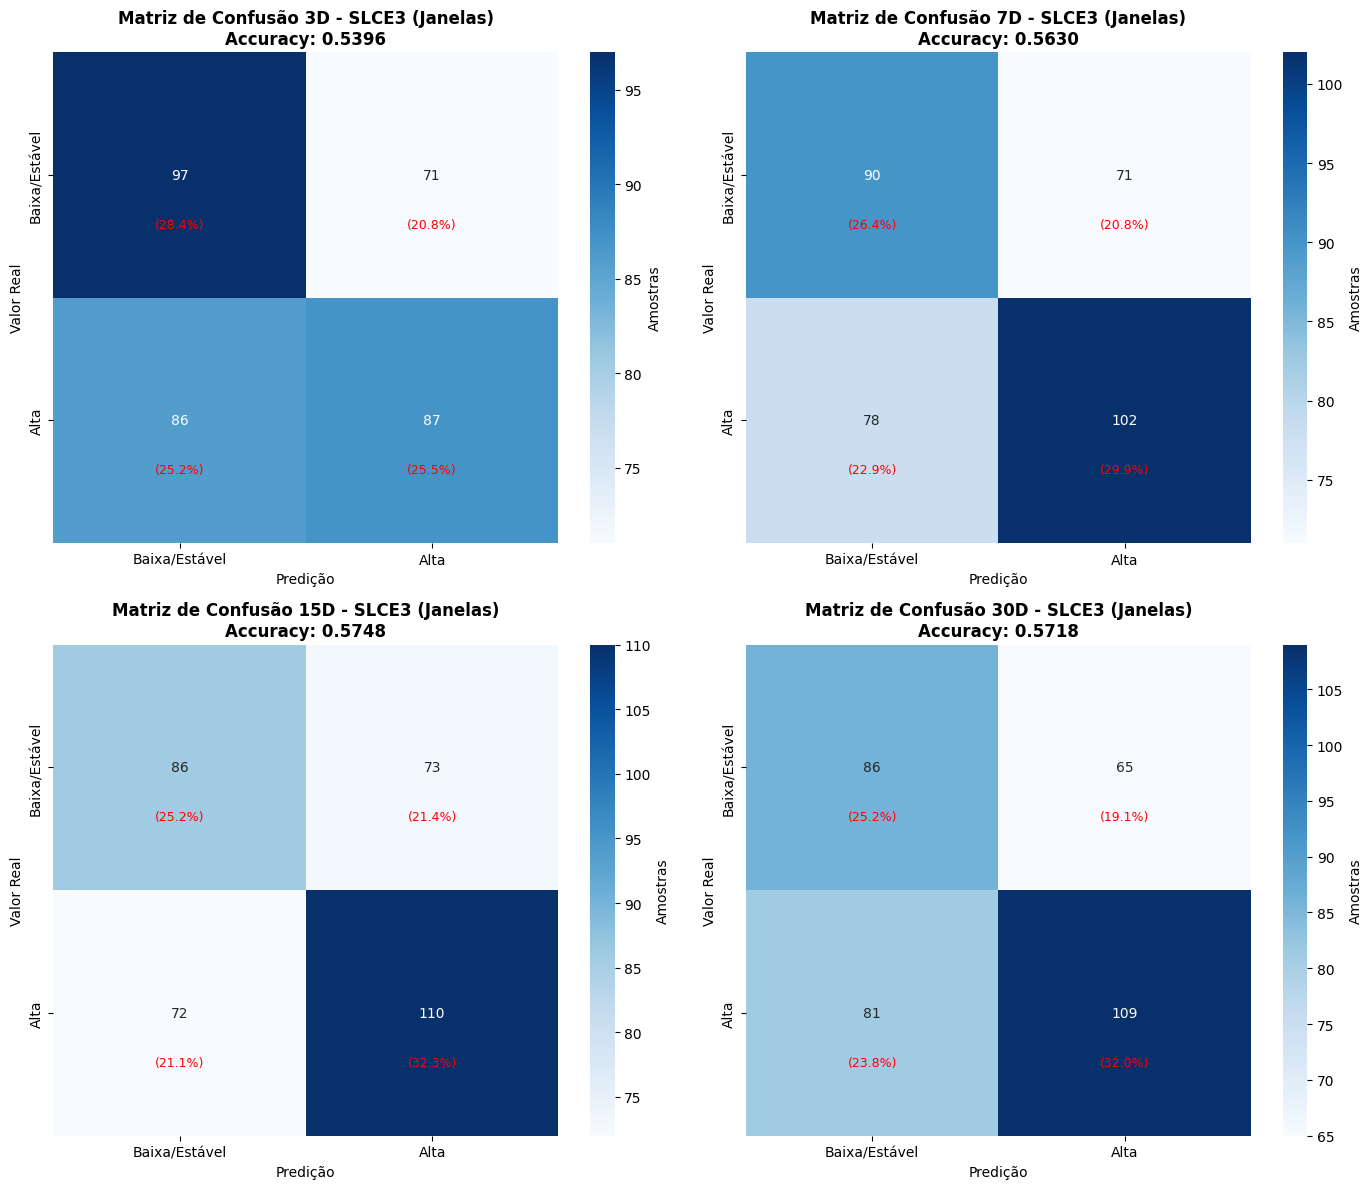

✓ Matrizes de confusão salvas


In [5]:
# Matrizes de Confusão
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred = model_data['y_pred']
    
    cm = confusion_matrix(y_test, y_pred)
    
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Baixa/Estável', 'Alta'],
                yticklabels=['Baixa/Estável', 'Alta'],
                cbar_kws={'label': 'Amostras'})
    
    ax.set_title(f'Matriz de Confusão {period.upper()} - SLCE3 (Janelas)\nAccuracy: {model_data["accuracy"]:.4f}', fontweight='bold')
    ax.set_xlabel('Predição')
    ax.set_ylabel('Valor Real')
    
    # Adicionar porcentagens
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            pct = (cm[i, j] / total) * 100
            ax.text(j+0.5, i+0.7, f'({pct:.1f}%)', ha='center', va='center', fontsize=9, color='red')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}matriz_confusao_slce3_janelas.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Matrizes de confusão salvas")

### Curvas ROC

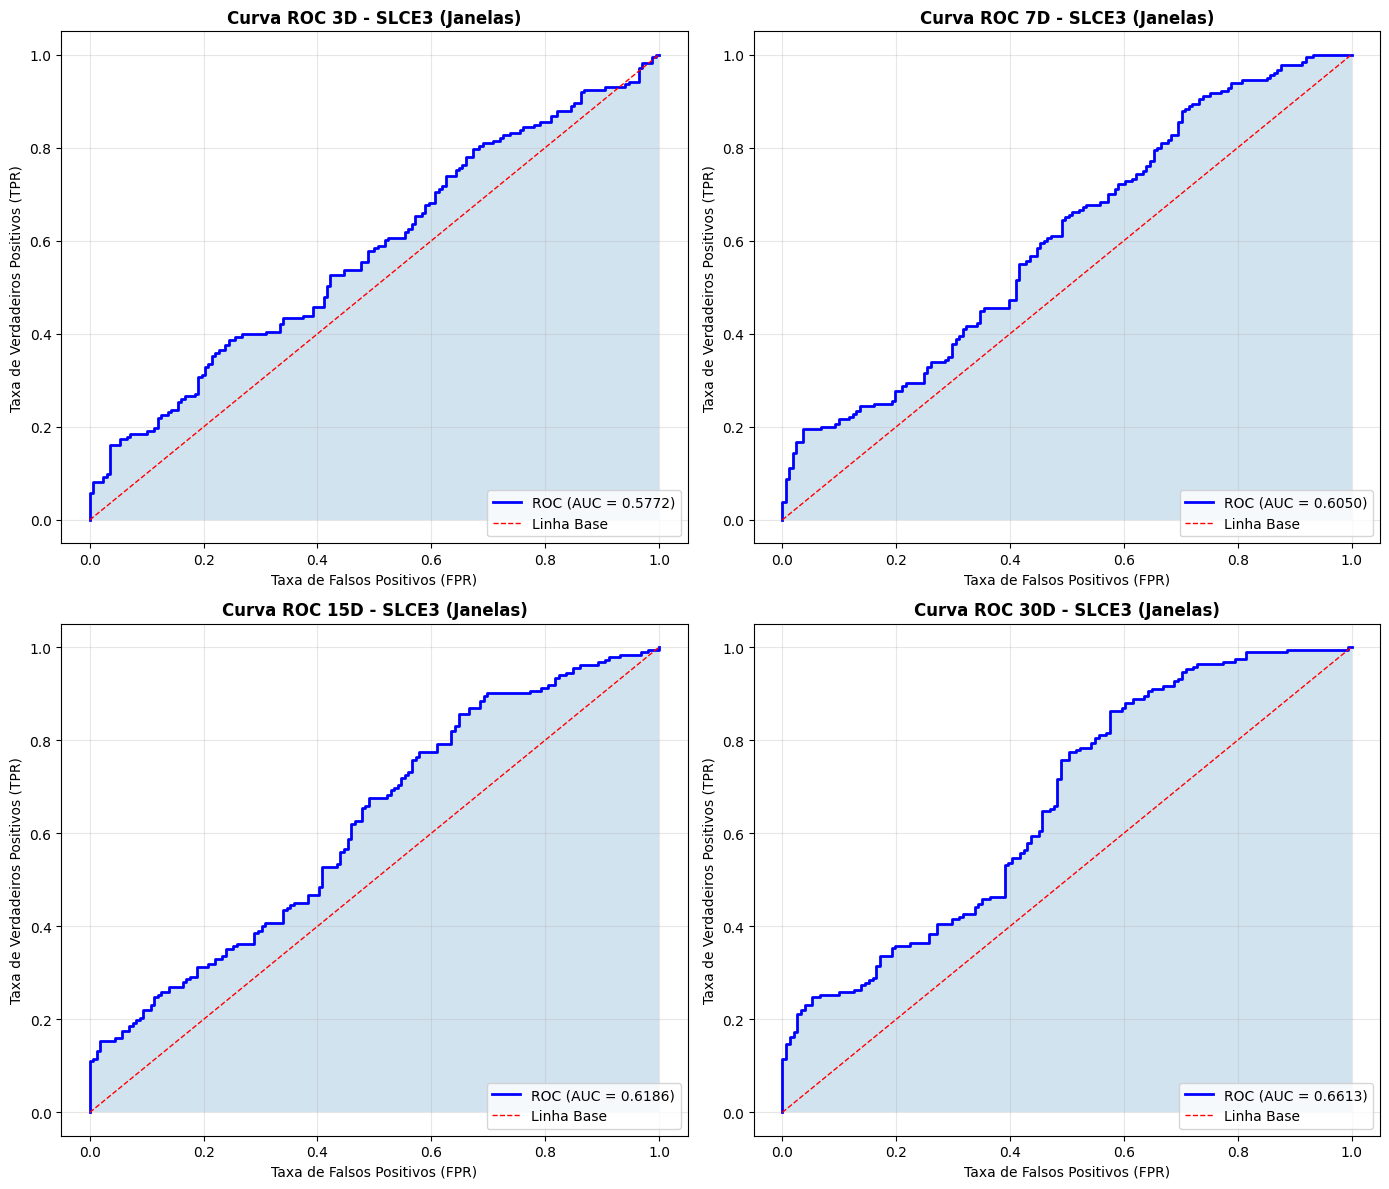

✓ Curvas ROC salvas


In [6]:
# Curvas ROC
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (period, model_data) in enumerate(models.items()):
    y_test = model_data['y_test']
    y_pred_proba = model_data['y_pred_proba']
    auc = model_data['auc_roc']
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    
    ax = axes[idx]
    ax.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {auc:.4f})')
    ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Linha Base')
    ax.fill_between(fpr, tpr, alpha=0.2)
    
    ax.set_title(f'Curva ROC {period.upper()} - SLCE3 (Janelas)', fontweight='bold')
    ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
    ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}curva_roc_slce3_janelas.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Curvas ROC salvas")

### Comparação das Métricas por Horizonte

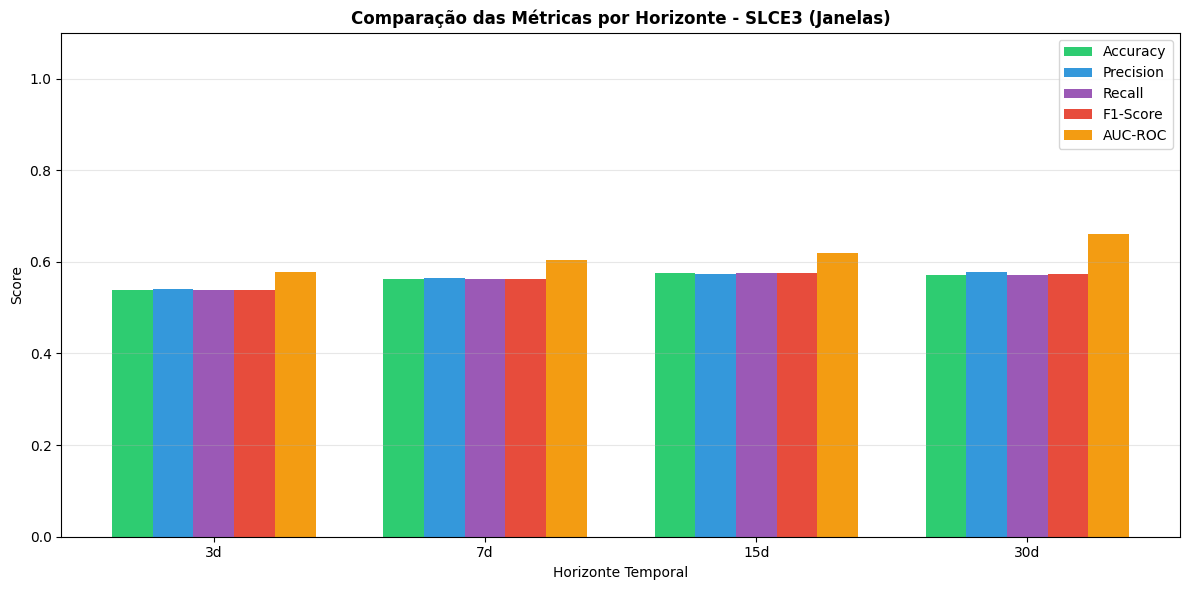

✓ Gráfico de comparação de métricas salvo


In [7]:
# Comparação das métricas
periods = ['3d', '7d', '15d', '30d']

accuracy_vals = [models[p]['accuracy'] for p in periods]
precision_vals = [models[p]['precision'] for p in periods]
recall_vals = [models[p]['recall'] for p in periods]
f1_vals = [models[p]['f1'] for p in periods]
auc_vals = [models[p]['auc_roc'] for p in periods]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(periods))
width = 0.15

bars1 = ax.bar(x - 2*width, accuracy_vals, width, label='Accuracy', color='#2ecc71')
bars2 = ax.bar(x - width, precision_vals, width, label='Precision', color='#3498db')
bars3 = ax.bar(x, recall_vals, width, label='Recall', color='#9b59b6')
bars4 = ax.bar(x + width, f1_vals, width, label='F1-Score', color='#e74c3c')
bars5 = ax.bar(x + 2*width, auc_vals, width, label='AUC-ROC', color='#f39c12')

ax.set_xlabel('Horizonte Temporal')
ax.set_ylabel('Score')
ax.set_title('Comparação das Métricas por Horizonte - SLCE3 (Janelas)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend(loc='upper right')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}comparacao_metricas_slce3_janelas.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráfico de comparação de métricas salvo")

### Evolução das Métricas por Horizonte

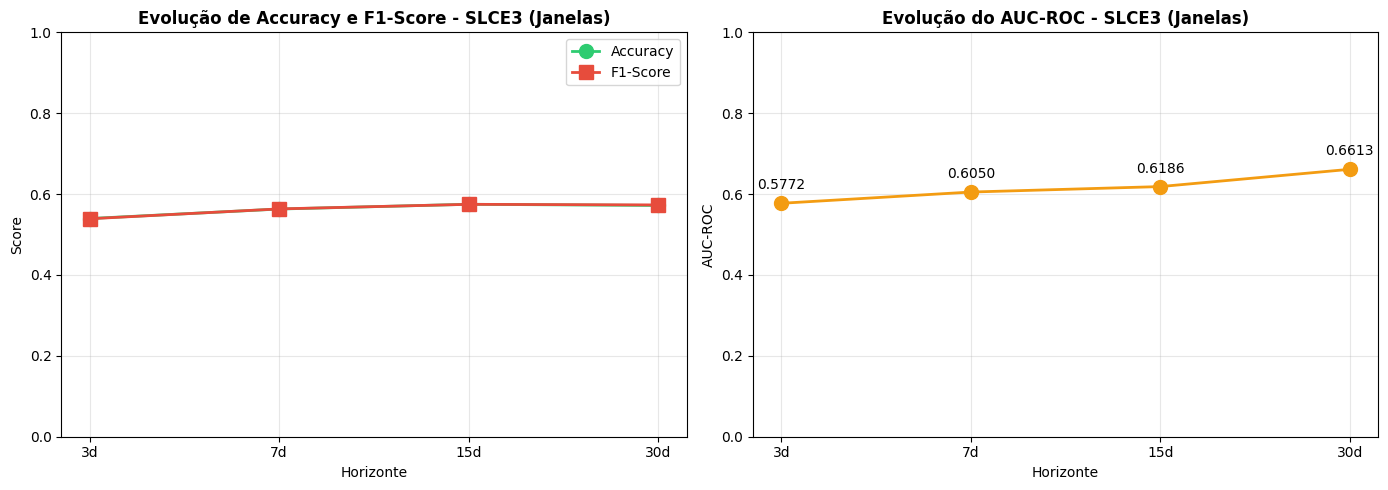

✓ Gráficos de evolução salvos


In [8]:
# Evolução das métricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy e F1-Score
axes[0].plot(periods, accuracy_vals, marker='o', linewidth=2, markersize=10, label='Accuracy', color='#2ecc71')
axes[0].plot(periods, f1_vals, marker='s', linewidth=2, markersize=10, label='F1-Score', color='#e74c3c')
axes[0].set_title('Evolução de Accuracy e F1-Score - SLCE3 (Janelas)', fontweight='bold')
axes[0].set_xlabel('Horizonte')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Plot AUC-ROC
axes[1].plot(periods, auc_vals, marker='o', linewidth=2, markersize=10, color='#f39c12')
axes[1].set_title('Evolução do AUC-ROC - SLCE3 (Janelas)', fontweight='bold')
axes[1].set_xlabel('Horizonte')
axes[1].set_ylabel('AUC-ROC')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

for i, v in enumerate(auc_vals):
    axes[1].annotate(f'{v:.4f}', (periods[i], v), textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}evolucao_metricas_slce3_janelas.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Gráficos de evolução salvos")

### Métricas da Classe Alta (Positiva)

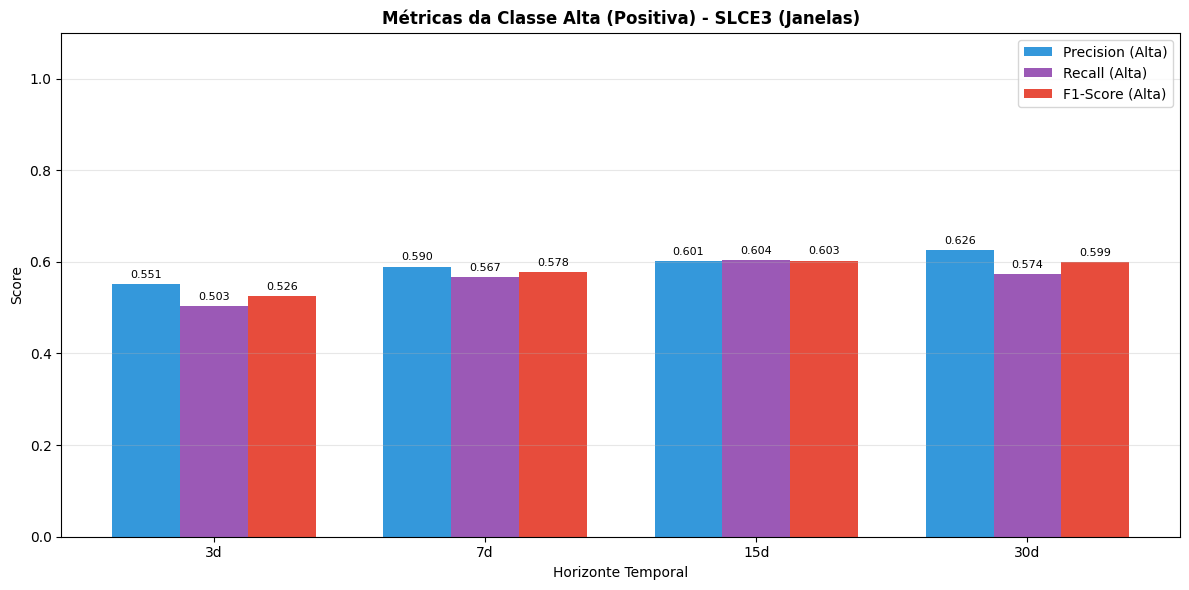

✓ Métricas da classe Alta salvas


In [9]:
# Métricas específicas da classe Alta
precision_alta_vals = [models[p]['precision_alta'] for p in periods]
recall_alta_vals = [models[p]['recall_alta'] for p in periods]
f1_alta_vals = [models[p]['f1_alta'] for p in periods]

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(periods))
width = 0.25

bars1 = ax.bar(x - width, precision_alta_vals, width, label='Precision (Alta)', color='#3498db')
bars2 = ax.bar(x, recall_alta_vals, width, label='Recall (Alta)', color='#9b59b6')
bars3 = ax.bar(x + width, f1_alta_vals, width, label='F1-Score (Alta)', color='#e74c3c')

ax.set_xlabel('Horizonte Temporal')
ax.set_ylabel('Score')
ax.set_title('Métricas da Classe Alta (Positiva) - SLCE3 (Janelas)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(periods)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

# Adicionar valores nas barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}metricas_classe_alta_slce3_janelas.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Métricas da classe Alta salvas")

### Relatório de Classificação Detalhado

In [10]:
# Relatório de classificação detalhado
print("\n" + "="*60)
print("RELATÓRIO DE CLASSIFICAÇÃO DETALHADO - SLCE3 (JANELAS)")
print("="*60)

for period, model_data in models.items():
    print(f"\n{'-'*50}")
    print(f"HORIZONTE: {period.upper()}")
    print(f"{'-'*50}")
    print(classification_report(model_data['y_test'], model_data['y_pred'], 
                                target_names=['Baixa/Estável', 'Alta']))


RELATÓRIO DE CLASSIFICAÇÃO DETALHADO - SLCE3 (JANELAS)

--------------------------------------------------
HORIZONTE: 3D
--------------------------------------------------
               precision    recall  f1-score   support

Baixa/Estável       0.53      0.58      0.55       168
         Alta       0.55      0.50      0.53       173

     accuracy                           0.54       341
    macro avg       0.54      0.54      0.54       341
 weighted avg       0.54      0.54      0.54       341


--------------------------------------------------
HORIZONTE: 7D
--------------------------------------------------
               precision    recall  f1-score   support

Baixa/Estável       0.54      0.56      0.55       161
         Alta       0.59      0.57      0.58       180

     accuracy                           0.56       341
    macro avg       0.56      0.56      0.56       341
 weighted avg       0.56      0.56      0.56       341


-------------------------------------------

### Resumo Final

In [11]:
print("\n" + "="*60)
print("RESUMO FINAL - REGRESSÃO LOGÍSTICA SLCE3 (DATASET JANELAS)")
print("="*60)
print(f"\n✓ 4 modelos treinados (horizontes: 3d, 7d, 15d, 30d)")
print(f"✓ Features base: {base_features}")
print(f"✓ Features lag: {lag_cols}")
print(f"✓ Total de features: {len(all_features)}")
print("\nMétricas por horizonte:")
for period in periods:
    m = models[period]
    print(f"  {period}: Acc={m['accuracy']:.4f}, F1={m['f1']:.4f}, AUC={m['auc_roc']:.4f}")

print("\nArquivos gerados:")
print("  - metricas_slce3_janelas.csv")
print("  - matriz_confusao_slce3_janelas.png")
print("  - curva_roc_slce3_janelas.png")
print("  - comparacao_metricas_slce3_janelas.png")
print("  - evolucao_metricas_slce3_janelas.png")
print("  - metricas_classe_alta_slce3_janelas.png")
print("="*60)


RESUMO FINAL - REGRESSÃO LOGÍSTICA SLCE3 (DATASET JANELAS)

✓ 4 modelos treinados (horizontes: 3d, 7d, 15d, 30d)
✓ Features base: ['Close', 'Low', 'High', 'Open']
✓ Features lag: ['Open_lag2d', 'Open_lag4d', 'Open_lag6d', 'High_lag2d', 'High_lag4d', 'High_lag6d', 'Low_lag2d', 'Low_lag4d', 'Low_lag6d', 'Close_lag2d', 'Close_lag4d', 'Close_lag6d']
✓ Total de features: 16

Métricas por horizonte:
  3d: Acc=0.5396, F1=0.5390, AUC=0.5772
  7d: Acc=0.5630, F1=0.5634, AUC=0.6050
  15d: Acc=0.5748, F1=0.5747, AUC=0.6186
  30d: Acc=0.5718, F1=0.5732, AUC=0.6613

Arquivos gerados:
  - metricas_slce3_janelas.csv
  - matriz_confusao_slce3_janelas.png
  - curva_roc_slce3_janelas.png
  - comparacao_metricas_slce3_janelas.png
  - evolucao_metricas_slce3_janelas.png
  - metricas_classe_alta_slce3_janelas.png
